In [57]:
# Objective: 
# Predict whether a loan applicant is likely to default on a loan. 

# Dataset: 
# Loan Prediction Dataset (available on Kaggle) 

# Instructions: 
# Handle missing data appropriately. 
# Visualize key features such as loan amount, education, and income. 
# Train a classification model like Logistic Regression or Decision Tree. 
# Evaluate the model using accuracy and a confusion matrix.

# importing required libraries such as pandas, matplotlib, seaborn, and scikit-learn with Label Encoder, Train Test Split, Logistic Resgression, and accuracy_score, and confusion_matrix

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix


In [17]:
# loading the loan prediction dataset using read_csv function and storing in df variable
df = pd.read_csv('loan_approval_dataset.csv')

In [16]:
# observing starting 5 rows of the dataset using head function
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [15]:
# checking for null values in the dataset to impute
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [24]:
# I found the extra space in start of the variable name, so renaming vaiables name to non-spaced variables name

df.rename(columns = {' education' : 'education'}, inplace = True)
df.rename(columns = {' no_of_dependents' : 'no_of_dependents'}, inplace = True)
df.rename(columns = {' self_employed' : 'self_employed'}, inplace = True)
df.rename(columns = {' income_annum' : 'income_annum'}, inplace = True)
df.rename(columns = {' loan_amount' : 'loan_amount'}, inplace = True)
df.rename(columns = {' loan_term' : 'loan_term'}, inplace = True)
df.rename(columns = {' cibil_score' : 'cibil_score'}, inplace = True)
df.rename(columns = {' residential_assets_value' : 'residential_assets_value'}, inplace = True)
df.rename(columns = {' commercial_assets_value' : 'commercial_assets_value'}, inplace = True)
df.rename(columns = {' luxury_assets_value' : 'luxury_assets_value'}, inplace = True)
df.rename(columns = {' bank_asset_value' : 'bank_asset_value'}, inplace = True)
df.rename(columns = {' loan_status' : 'loan_status'}, inplace = True)


In [25]:
# After imputation, our dataset has no na/null value. So, now we are converting our nominal/categorical data into numerical data because the machine learning model don't understand text

le = LabelEncoder()
df['education'] = le.fit_transform(df['education'])
df['self_employed'] = le.fit_transform(df['self_employed'])
df['loan_status'] = le.fit_transform(df['loan_status'])

Text(0, 0.5, 'Frequency')

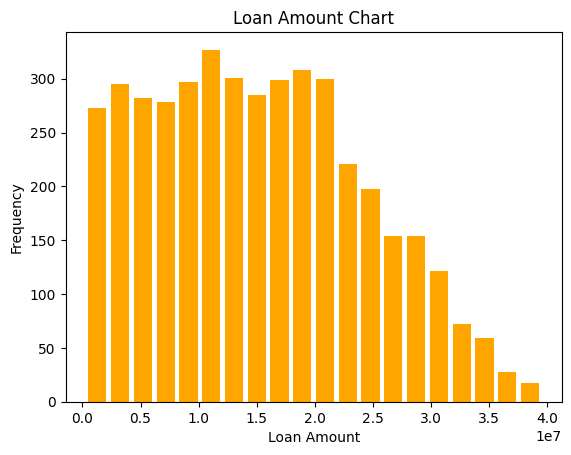

In [32]:
# visualizing the loan amount and the frequency of borrower

plt.hist(df['loan_amount'], rwidth = 0.8, color='orange', bins = 20)
plt.title('Loan Amount Chart')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

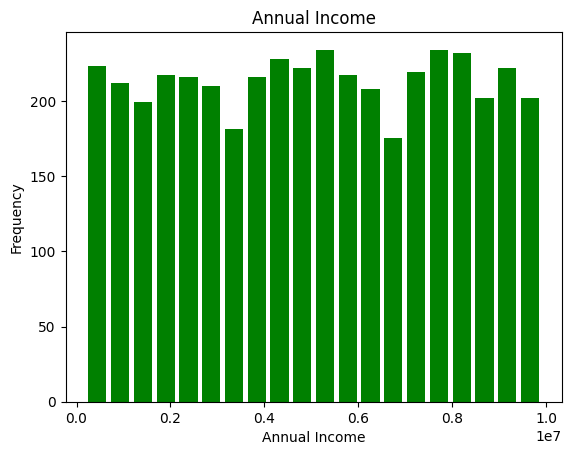

In [33]:
# visualizing the annual income of the borrower

plt.hist(df['income_annum'], rwidth=0.8, color='green', bins=20)
plt.title('Annual Income')
plt.xlabel('Annual Income')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

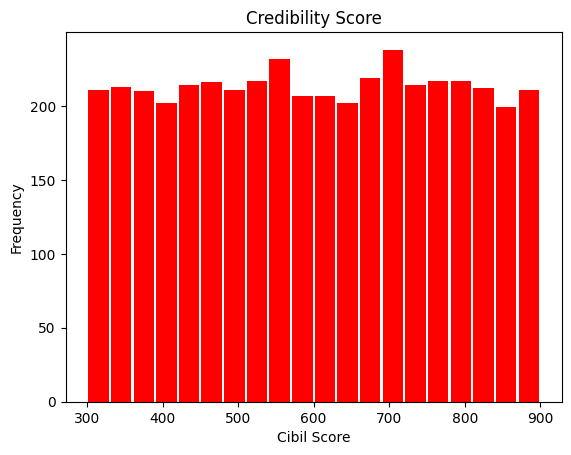

In [34]:
# visualizing the credibility score of the borrower to know how much past loan the borrower has returned

plt.hist(df['cibil_score'], rwidth=0.9, color='red', bins=20)
plt.title('Credibility Score')
plt.xlabel('Cibil Score')
plt.ylabel('Frequency')

In [37]:
# Defining features (X) and target (y) variables. X variables are independent while y is our target and dependent variable which we will predict.
# loan_status is our target variable so we are removing it from the X(independent variables), and storing it in Y (target variable)

X = df.drop(['loan_id', 'loan_status'], axis=1)
y = df['loan_status']

In [39]:
# splitting the data into train and test using train_test_split with splitting of 80% train and 20% test data. 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
# Fitting the Logistic Regression model to the training varibles( X_train and y_train)

model = LogisticRegression(max_iter=2000)
model = model.fit(X_train, y_train) 

In [ ]:
# predicting the model on X_test varible using predict function

y_pred = model.predict(X_test)
print(y_pred)

In [54]:
# finding the accuracy score of the model to analyze how efficients are the predictions

accuracy = accuracy_score(y_test, y_pred)
print('Accuracy: ', accuracy)

Accuracy:  0.7985948477751756


In [55]:
# finding confusion matrix of the model 

cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix: ', cm)

Confusion Matrix:  [[488  48]
 [124 194]]


Text(50.722222222222214, 0.5, 'Actual')

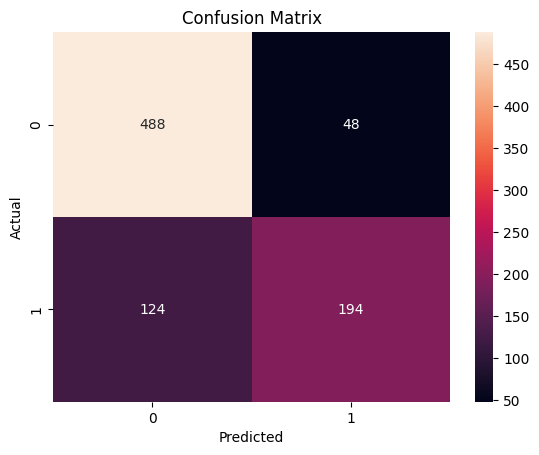

In [58]:
# visualizing the confusion matrix using heatmap 

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
